In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
temp_df = pd.read_excel('/Users/u0186653/Desktop/research/dingen/raw/Grain/08_CornGrain/08-MG_Rev489_RESULTS_TEMPVAR.xlsx', sheet_name='Foglio1', usecols='B', skiprows=7, nrows=7)
temperatures = temp_df.iloc[:, 0].tolist()

# Example usage
fold = "/Users/u0186653/Desktop/research/dingen/raw/Grain/08_CornGrain/Temperatura/nstd"
sensor_files = os.listdir(fold)   

## Spettri: stesso sensore, diverse temperature

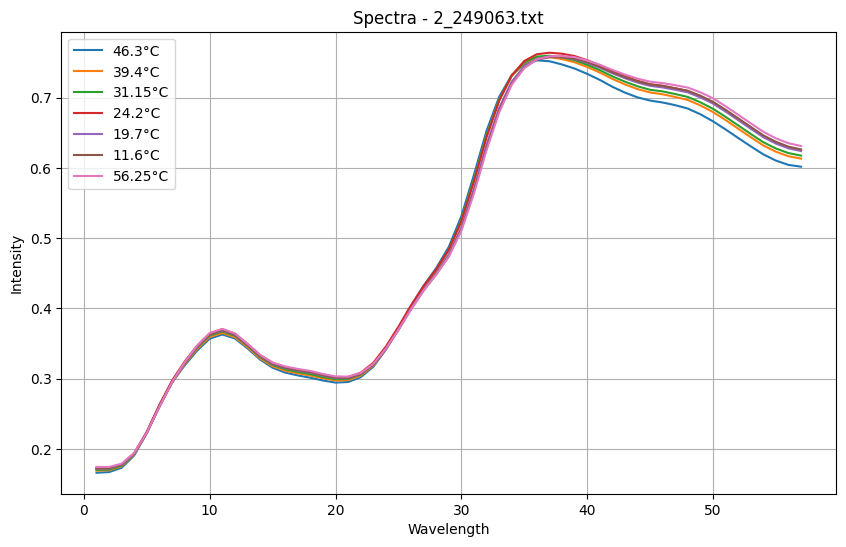

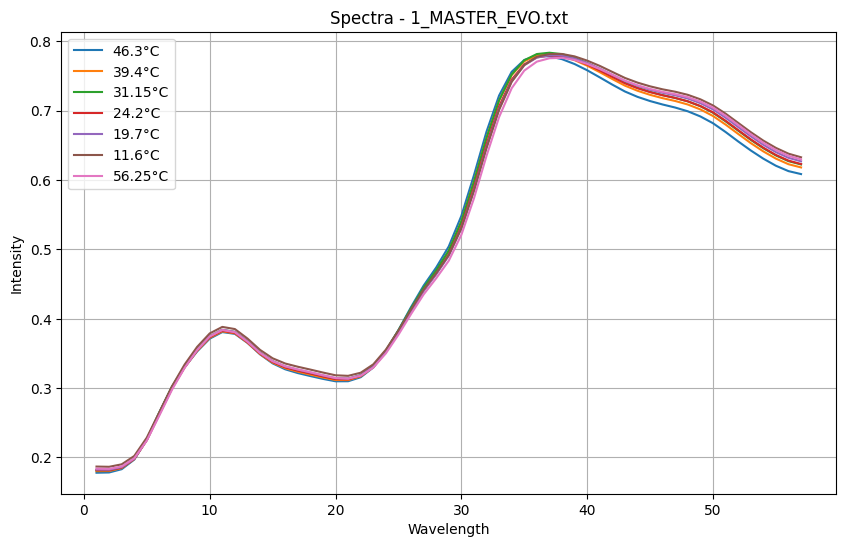

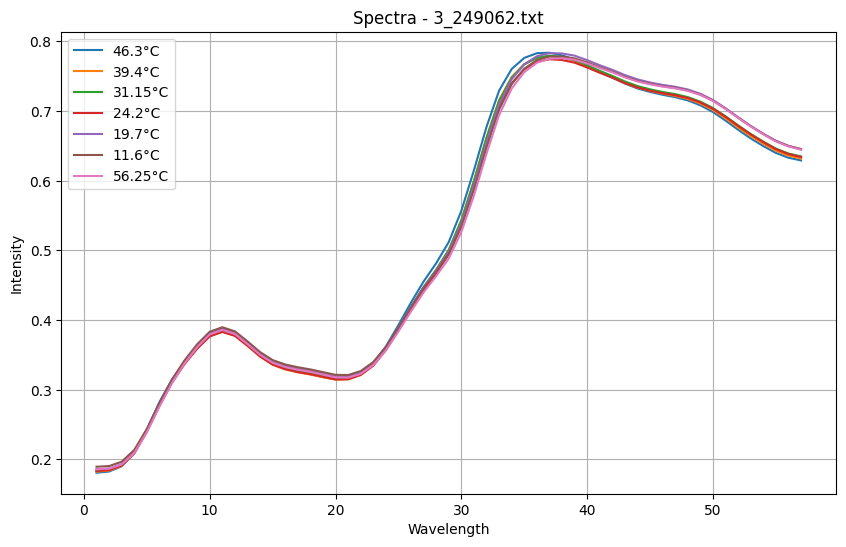

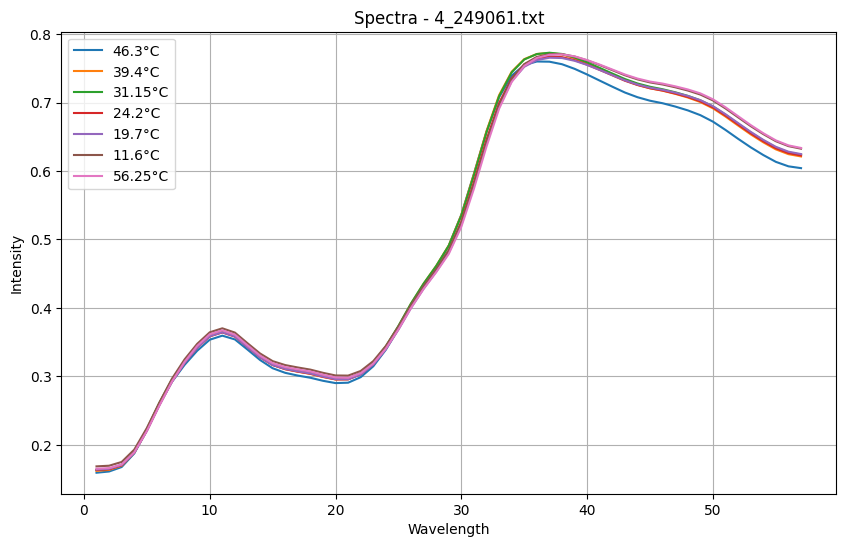

In [4]:
for sensor_file in sensor_files:
    # Read spectral data (assuming each row is a spectrum)
    spectra = pd.read_csv(os.path.join(fold, sensor_file), header=None, sep="\t")  # Shape: (N_spectra, wavelengths)
    
    plt.figure(figsize=(10, 6))
    for i in range(len(temperatures)):
        plt.plot(spectra.iloc[i, 1:58], label=f'{temperatures[i]}°C')
    plt.title(f'Spectra - {sensor_file}')
    plt.xlabel('Wavelength')
    plt.ylabel('Intensity')
    plt.legend()
    plt.grid(True)
    plt.show()

## Spettri: stessa temperatura, diversi sensori

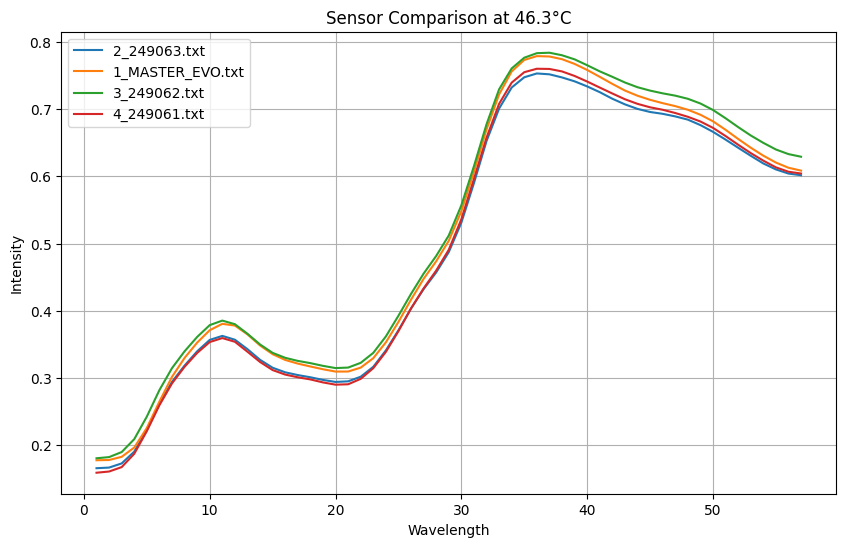

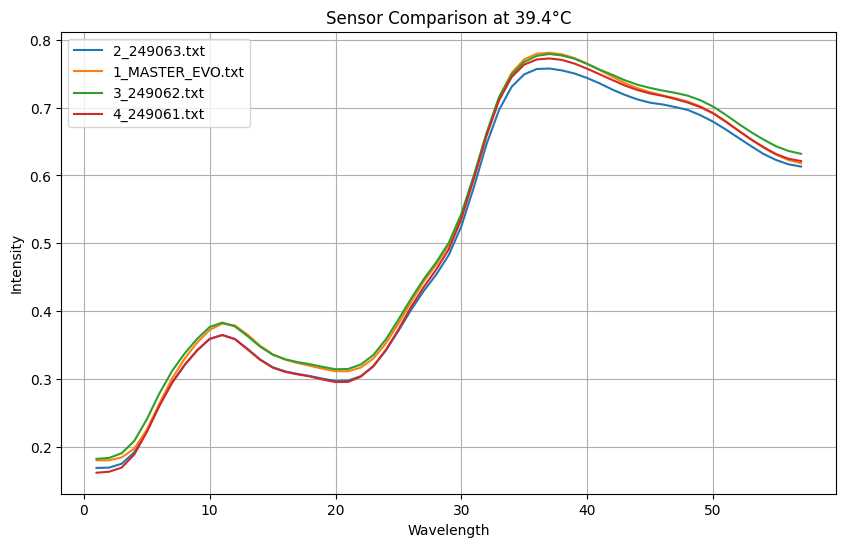

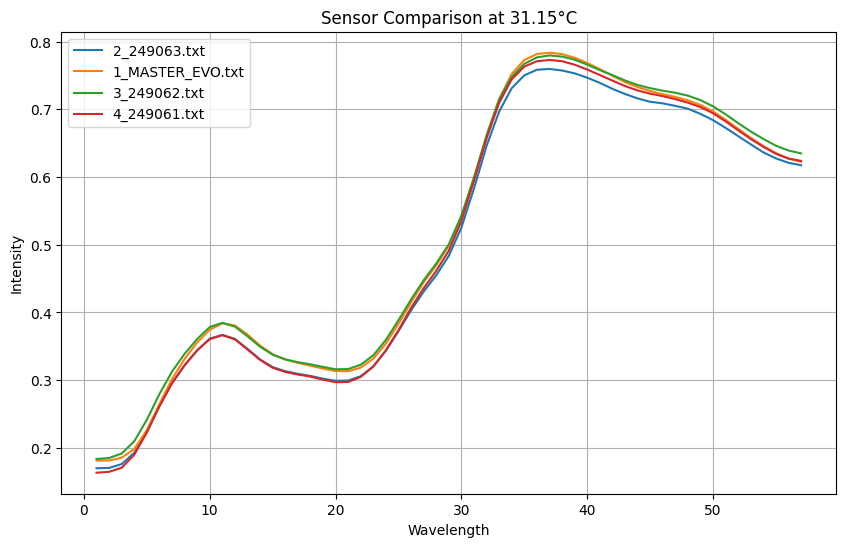

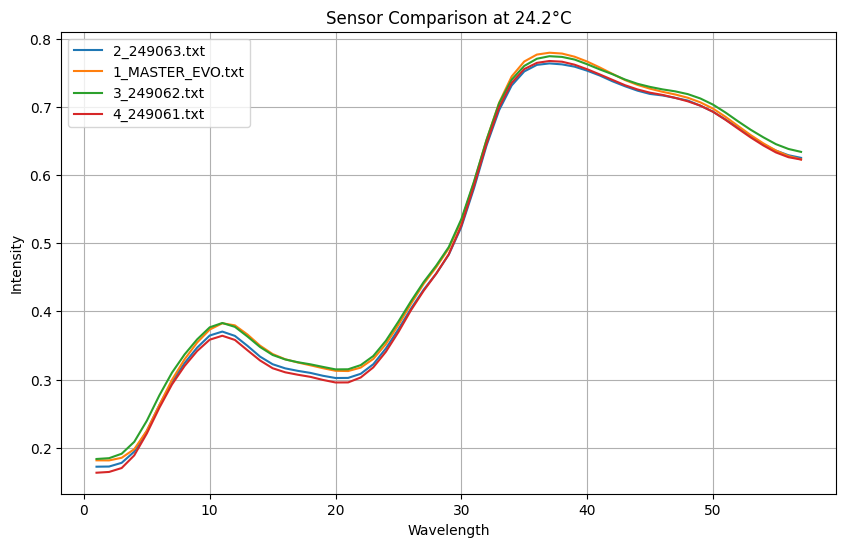

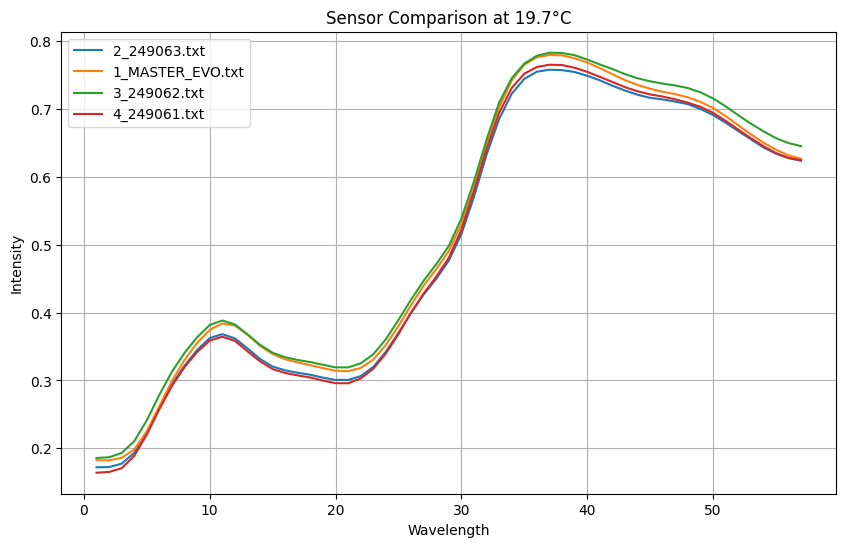

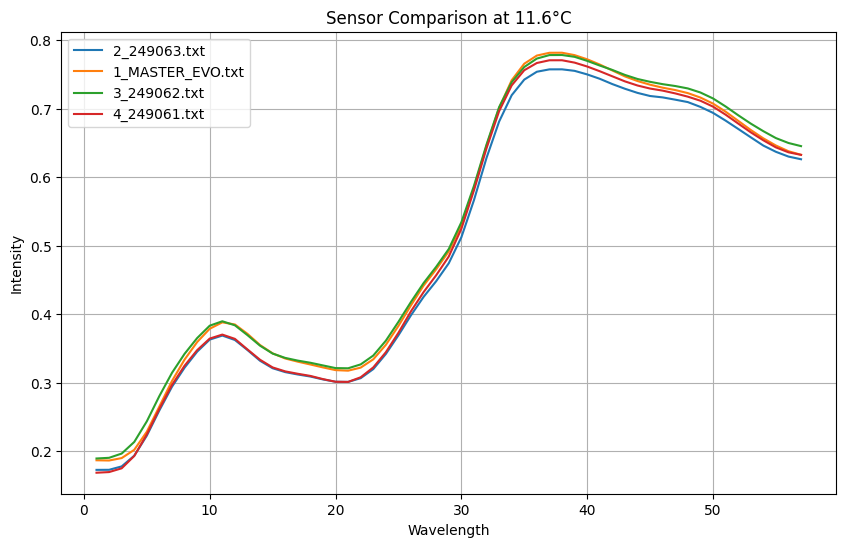

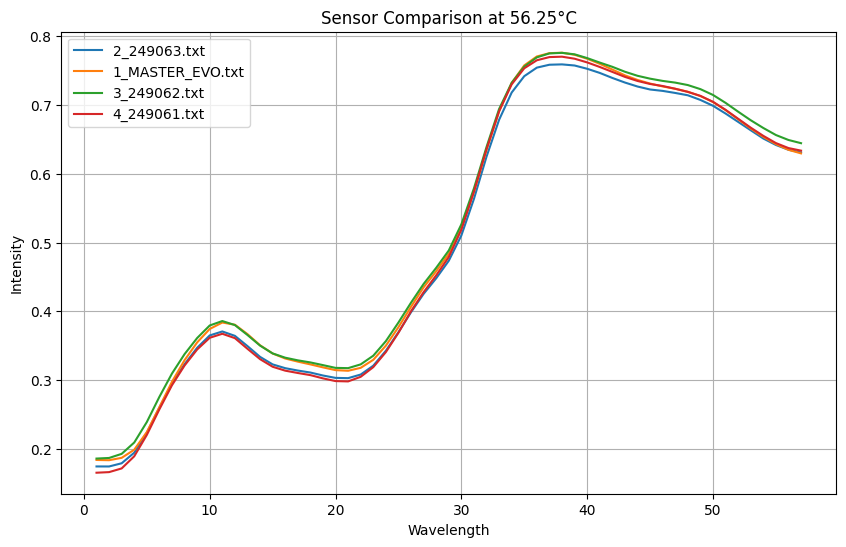

In [8]:
for idx, temp in enumerate(temperatures):
    plt.figure(figsize=(10, 6))
    for sensor_file in sensor_files:
        df = pd.read_csv(os.path.join(fold, sensor_file), header=None, sep="\t")
        plt.plot(df.iloc[idx, 1:58], label=sensor_file)

    plt.title(f'Sensor Comparison at {temperatures[idx]}°C')
    plt.xlabel('Wavelength')
    plt.ylabel('Intensity')
    plt.legend()
    plt.grid(True)
    plt.show()

## Relazione tra frequenze selezionate da XGB e spettri
le frequenze che vediamo come linee verticali sono le 15 più frequenti tra tutti i modelli addestrati per quel nutriente

In [65]:
from collections import Counter

root_dir = '/Users/u0186653/Desktop/research/dingen/deepnir/src/outputs/xgb/trained_models/58freqs'
nutrients = ['ADF', 'Ash', 'Crude Fat', 'Crude Fib.', 'DM', 'NDF', 'Protein', 'Starch']
# Store all frequencies per nutrient
nutrient_freqs = {nutrient: [] for nutrient in nutrients}
freq_counts = {nutrient: Counter() for nutrient in nutrients}
top_freqs = {}

# Traverse directory tree
for crop_folder in os.listdir(root_dir):
    crop_path = os.path.join(root_dir, crop_folder)
    if not os.path.isdir(crop_path):
        continue

    for nutrient in nutrients:
        # Match CSV by nutrient in filename
        file_path = os.path.join(crop_path, f"{nutrient}_regr_selected_freq.csv")
        if os.path.exists(file_path):
            with open(file_path, 'r') as f:
                line = f.readline().strip()
                freqs = [int(x) for x in line.split(',') if x.strip().isdigit()]
                freq_counts[nutrient].update(freqs)

# Show top 5 most common frequencies per nutrient
for nutrient, counts in freq_counts.items():
    if counts:
        top_freqs[nutrient] = [frq for frq, cnt in counts.most_common(15)]

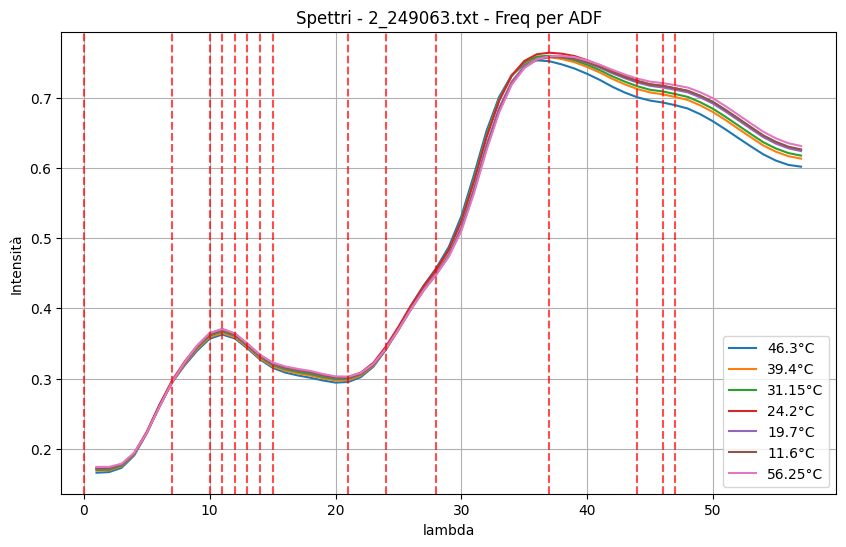

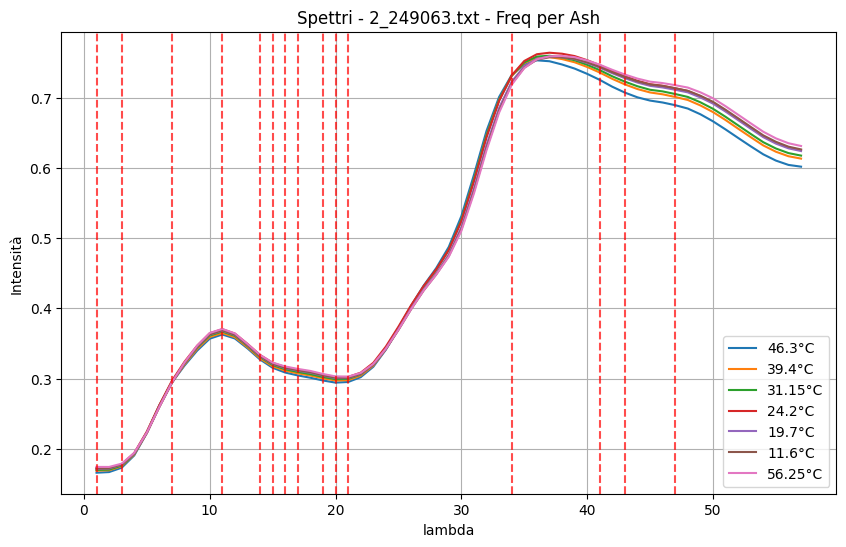

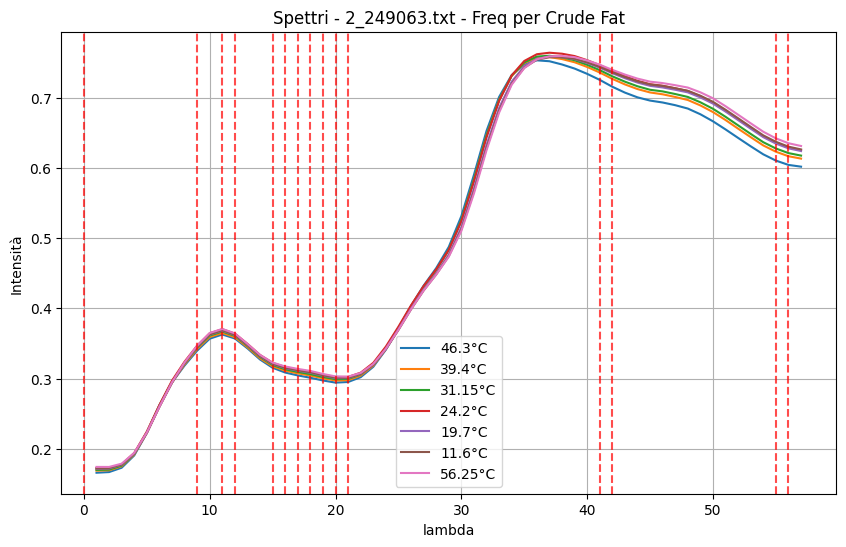

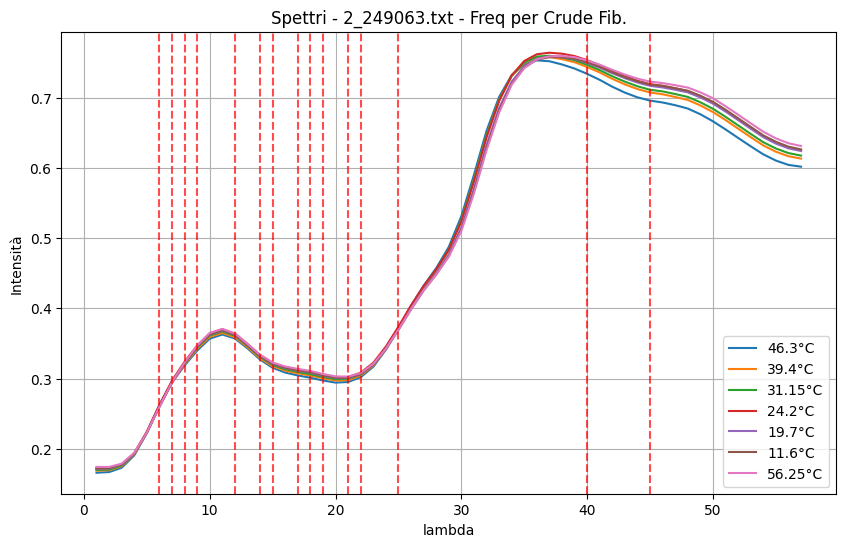

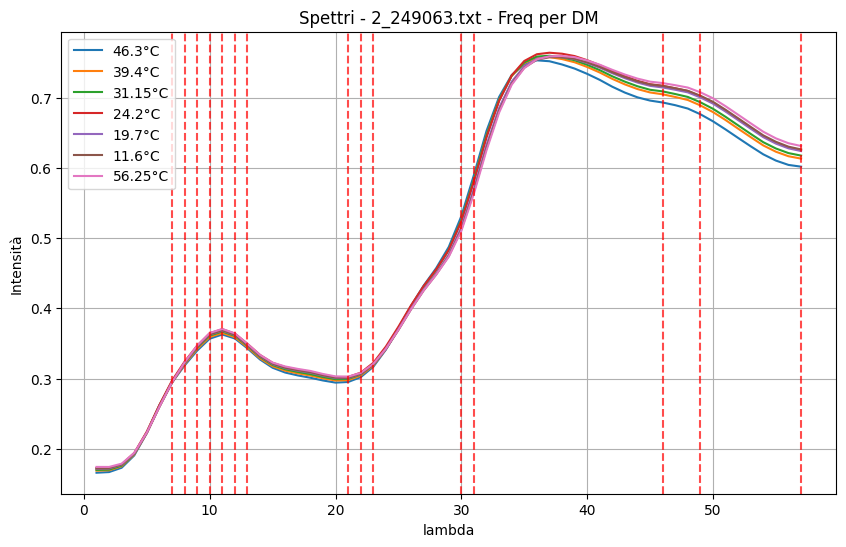

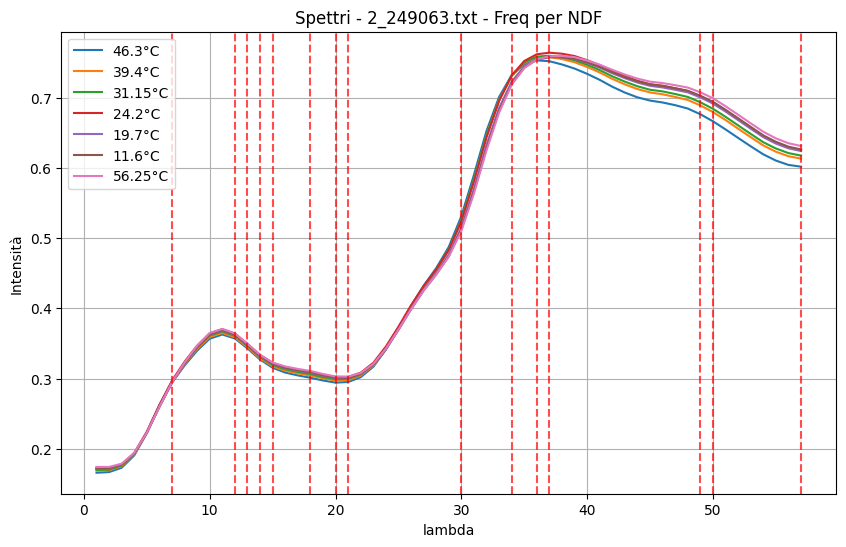

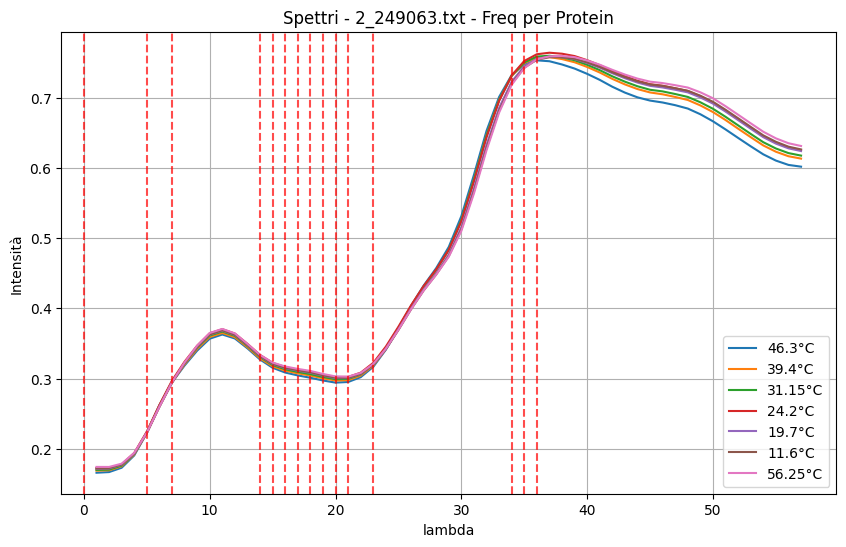

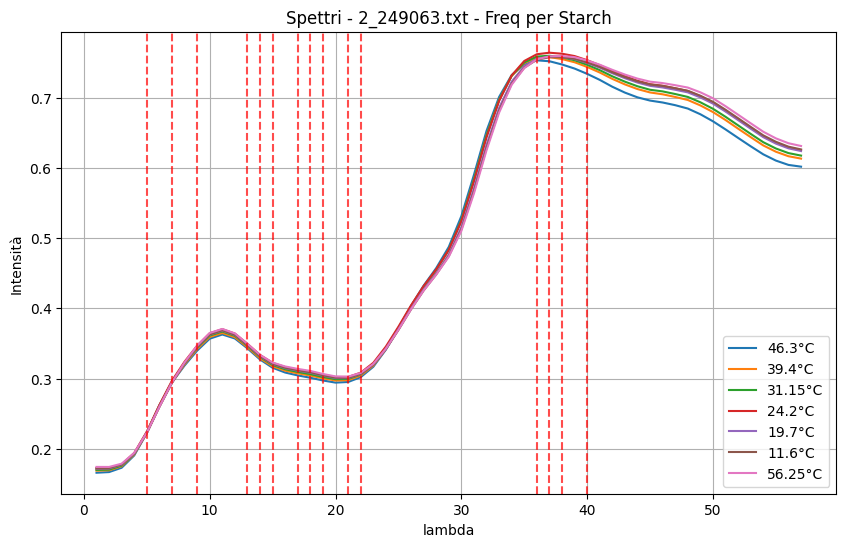

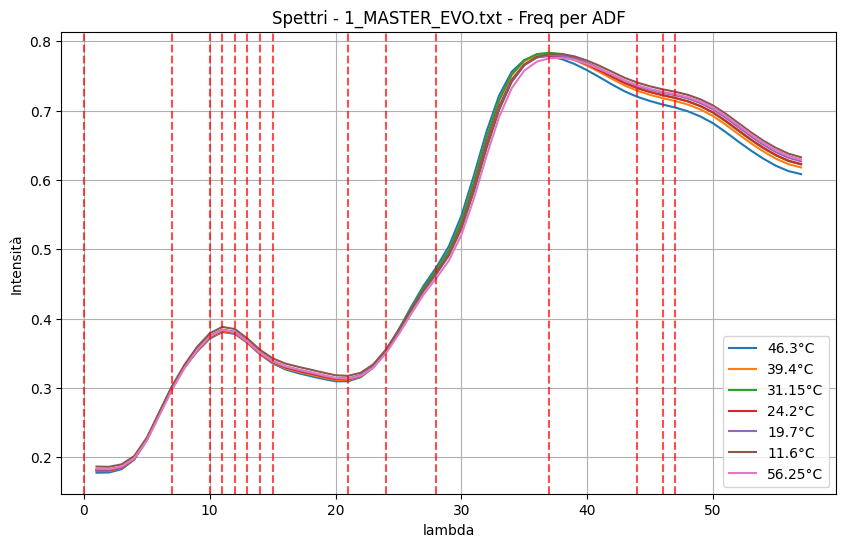

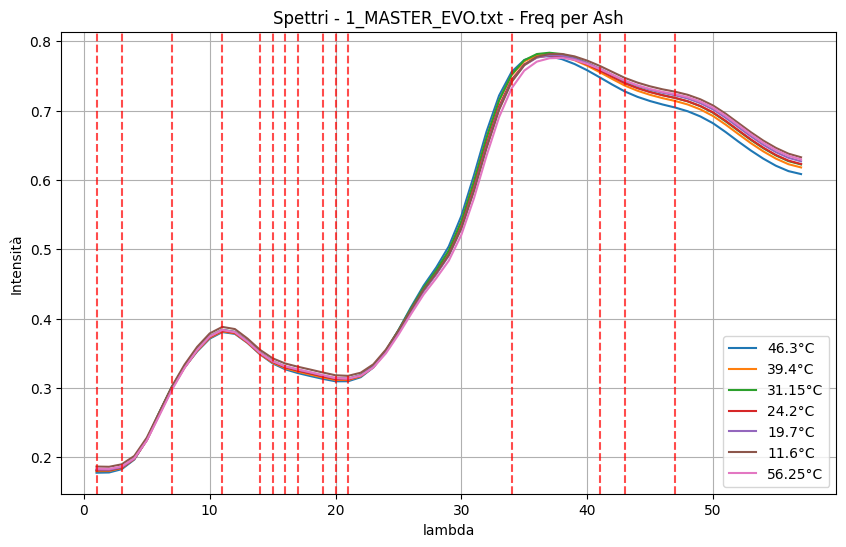

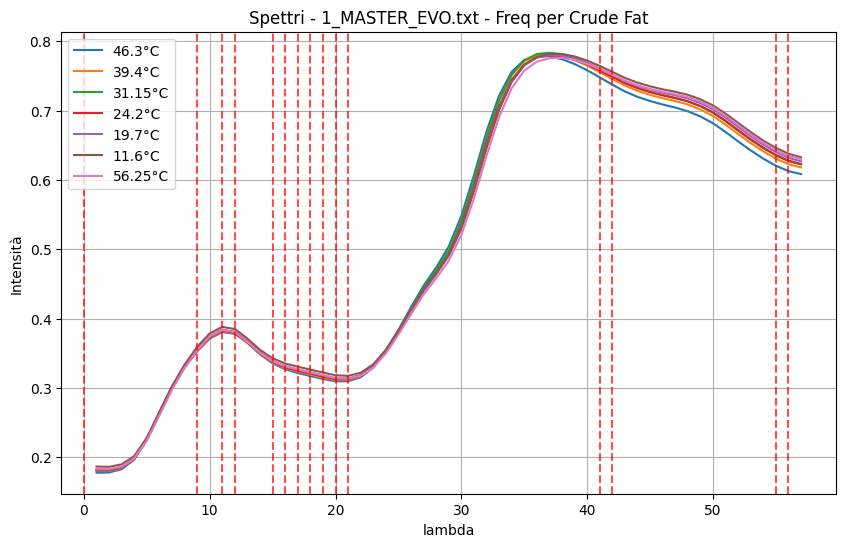

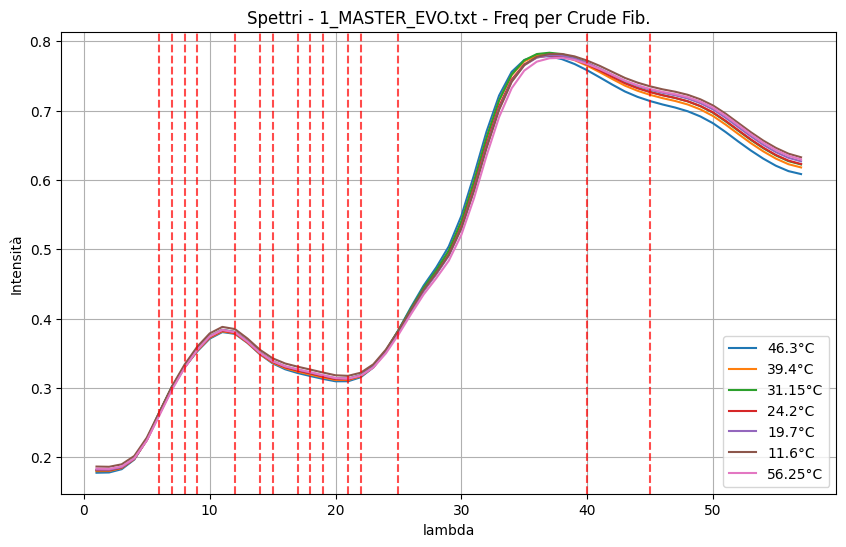

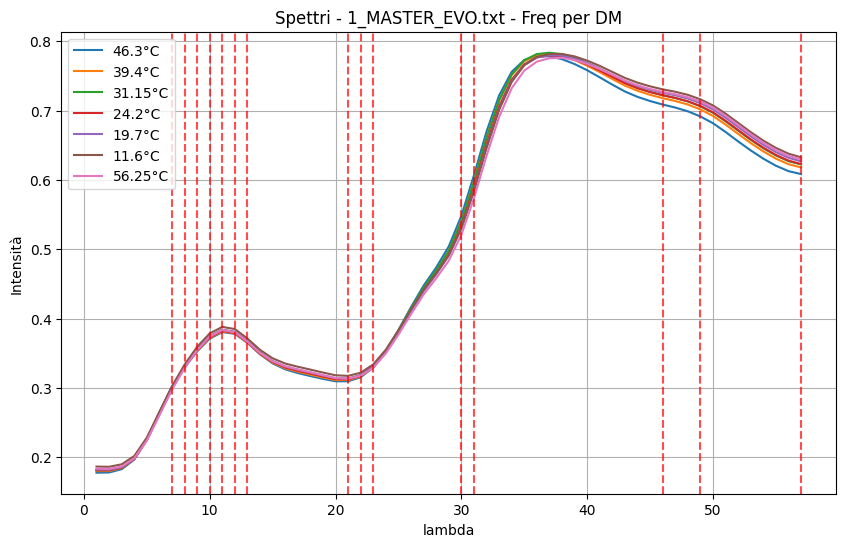

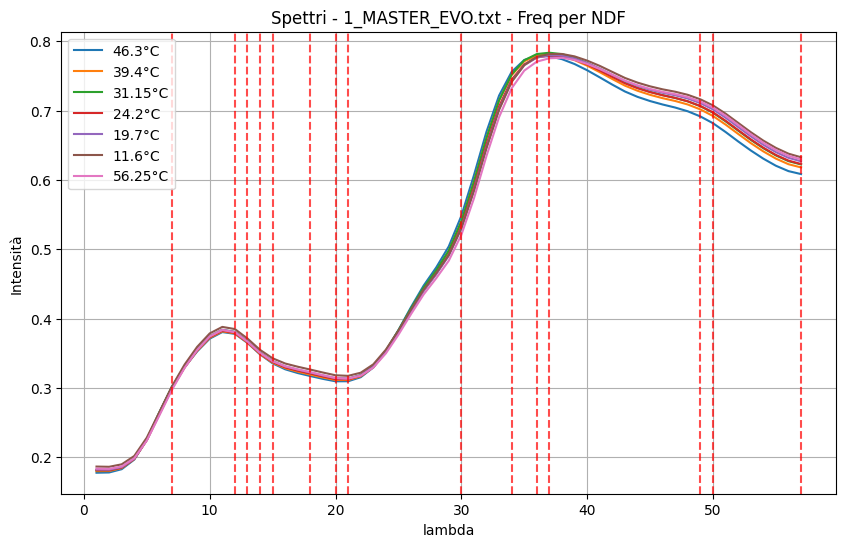

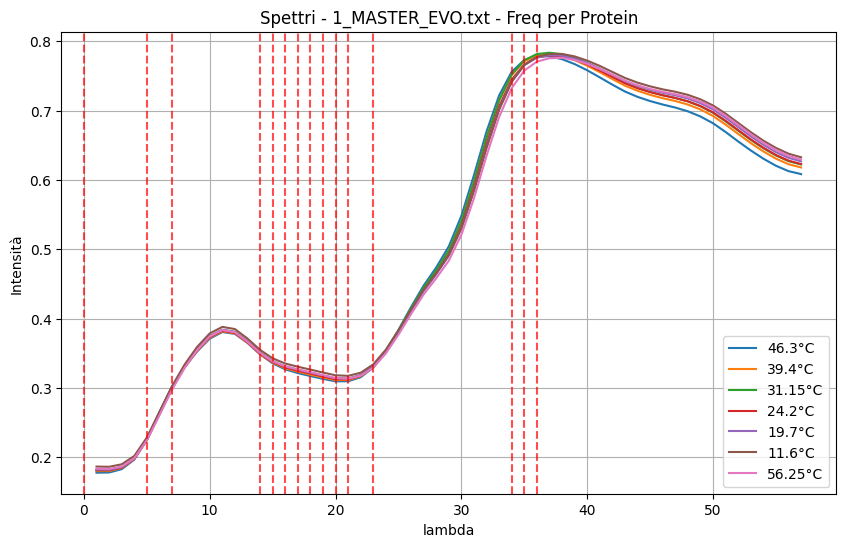

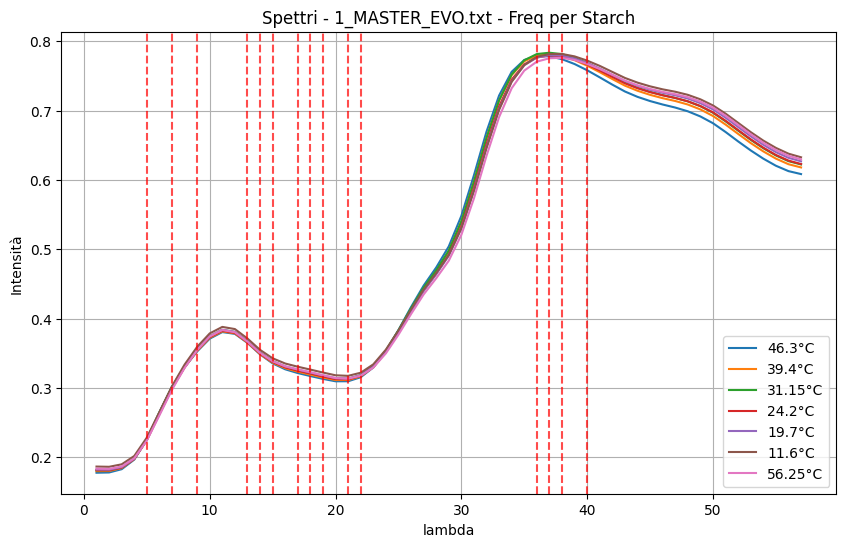

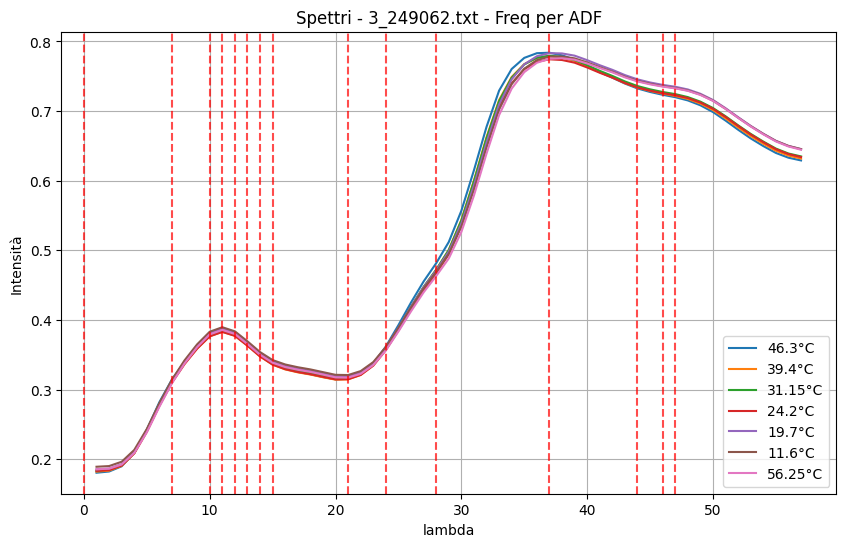

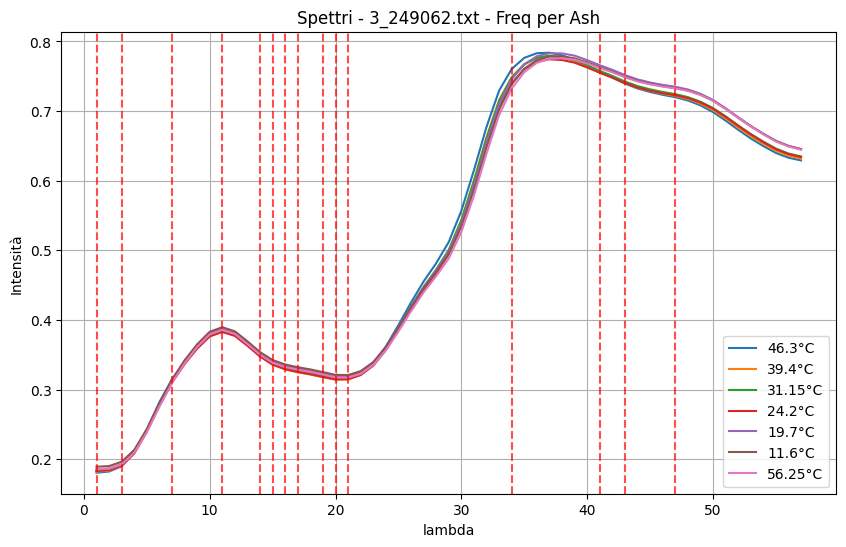

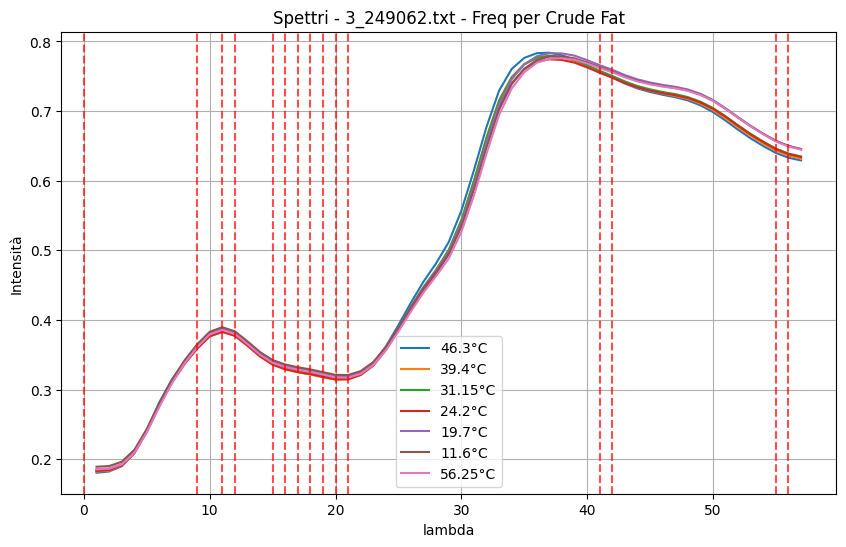

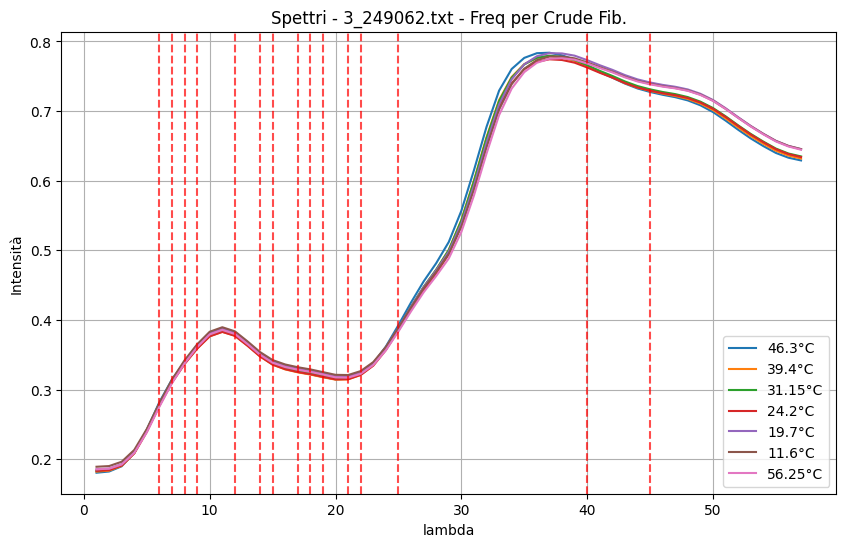

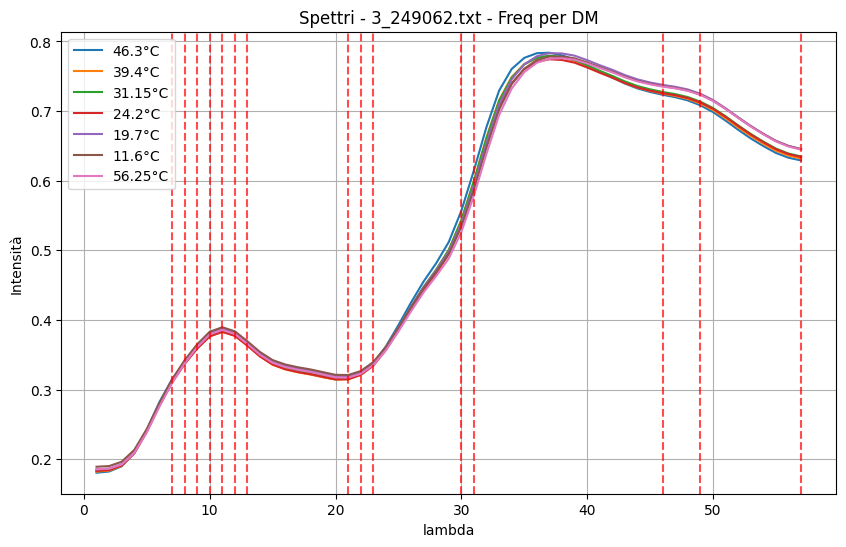

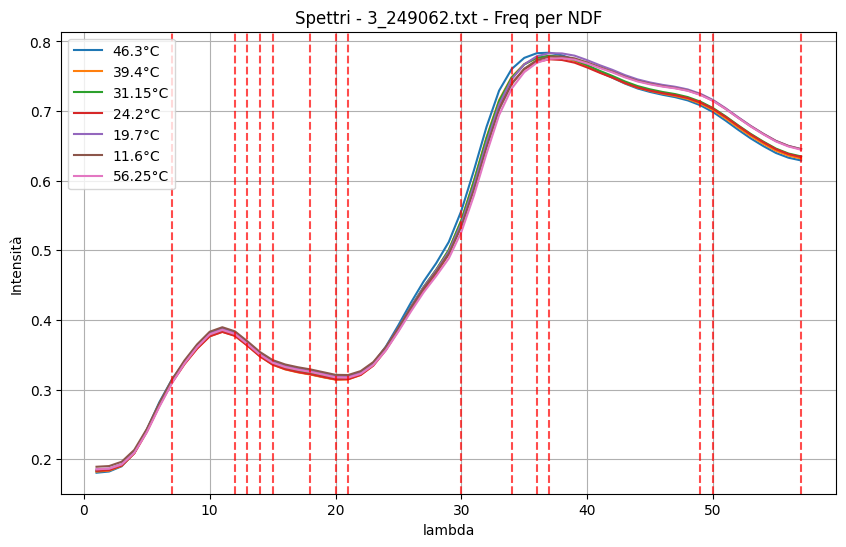

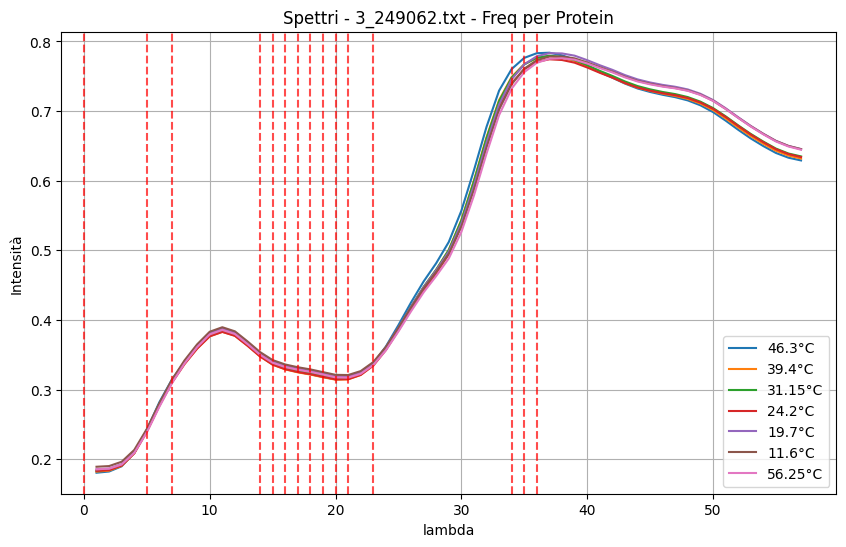

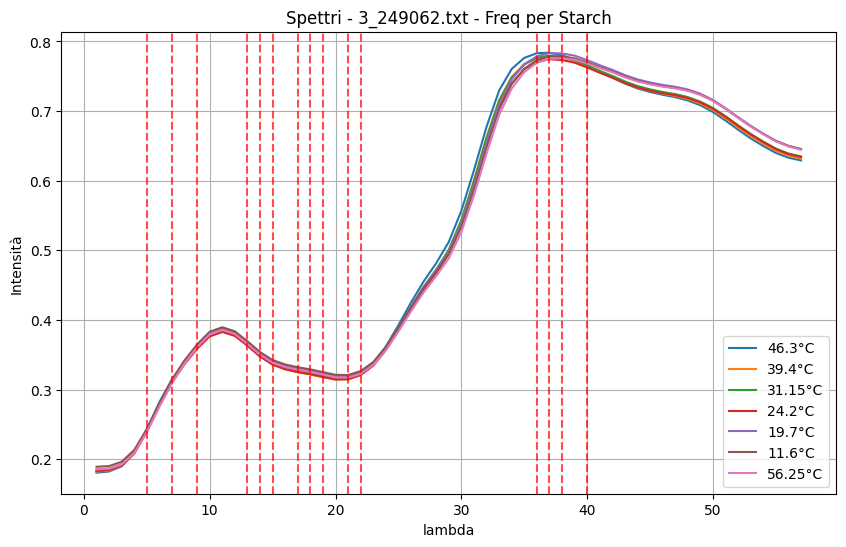

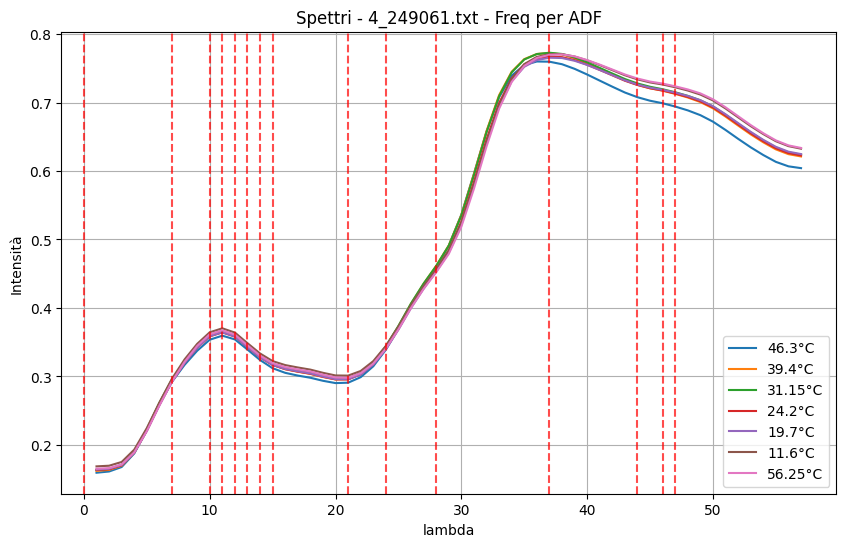

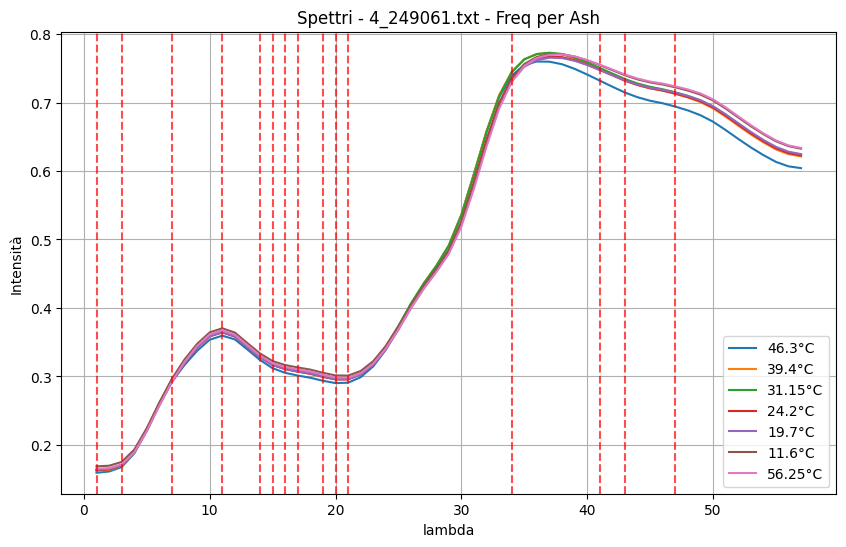

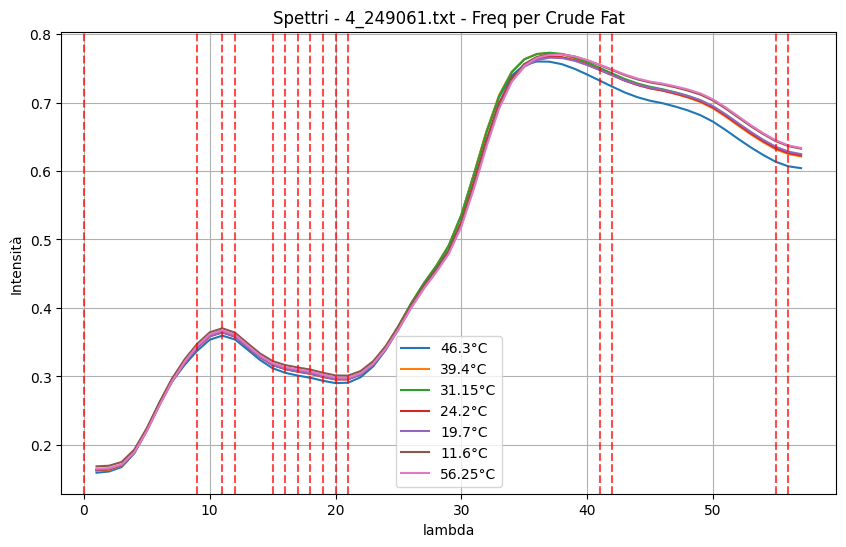

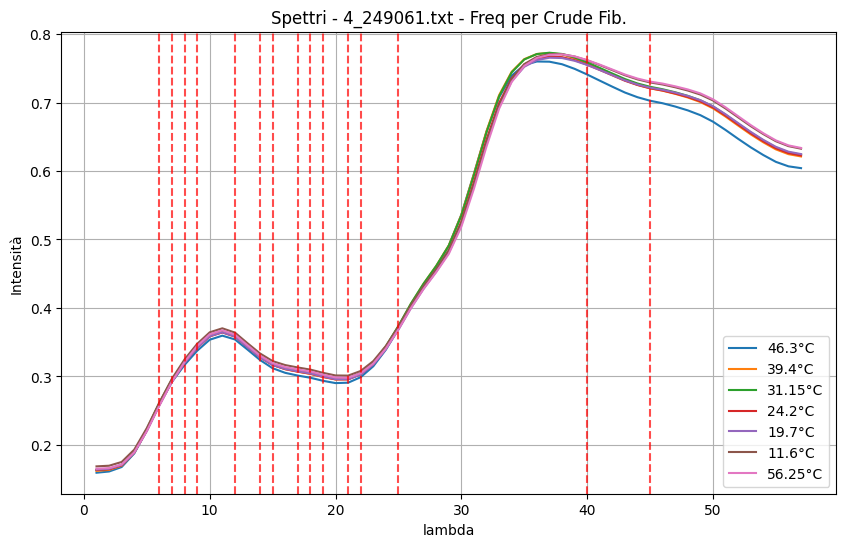

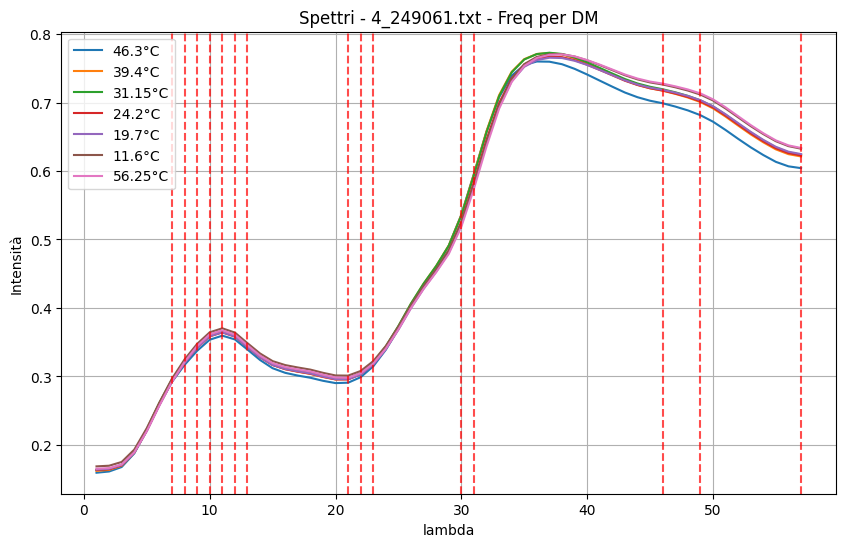

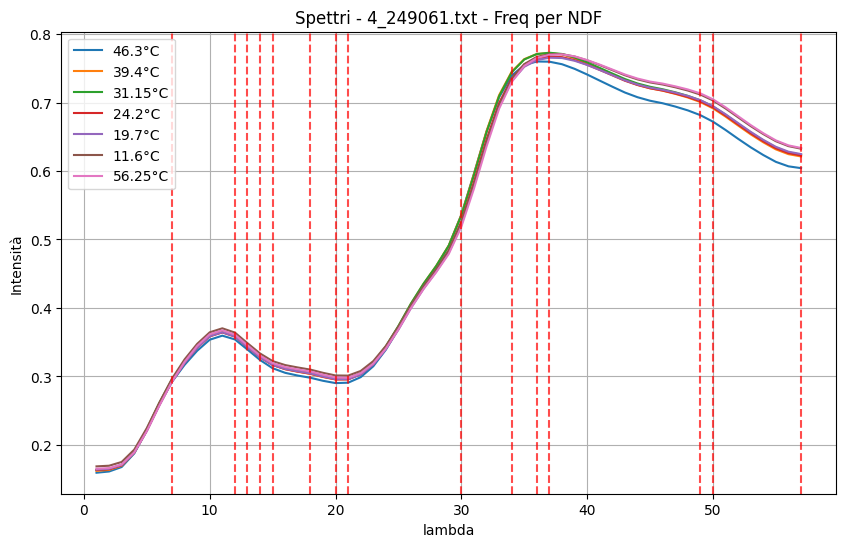

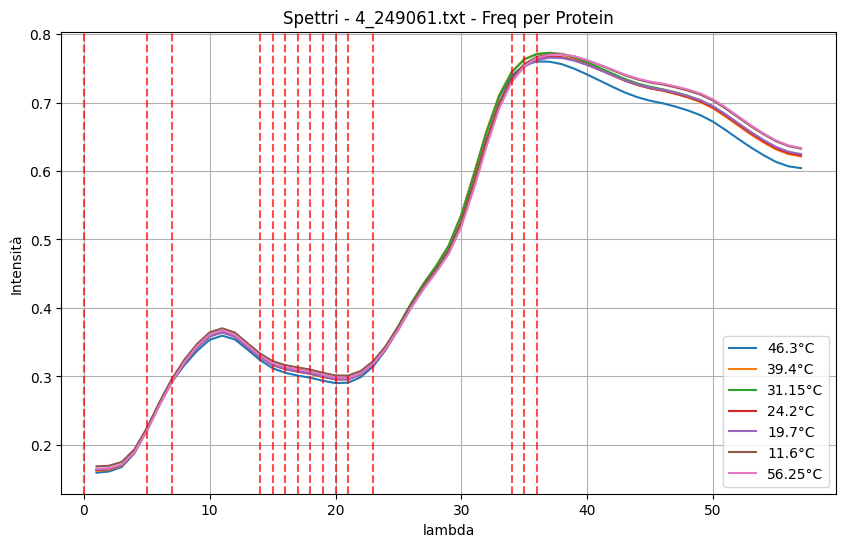

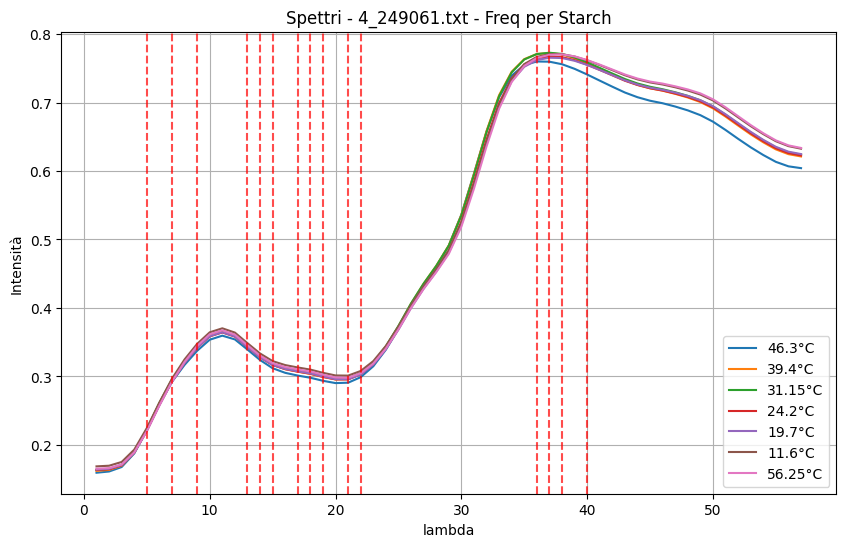

In [66]:
for sensor_file in sensor_files:
    # Read spectral data (assuming each row is a spectrum)
    spectra = pd.read_csv(os.path.join(fold, sensor_file), header=None, sep="\t")  # Shape: (N_spectra, wavelengths)
    
    # Highlight important frequencies
    for nutr, freqs in top_freqs.items():

        plt.figure(figsize=(10, 6))

        for i in range(len(temperatures)):
            plt.plot(spectra.iloc[i, 1:58], label=f'{temperatures[i]}°C')
        
        plt.title(f'Spettri - {sensor_file} - Freq per {nutr}')
        plt.xlabel('lambda')
        plt.ylabel('Intensità')
        # plt.legend()
        plt.grid(True)
        
        for freq in freqs:
            plt.axvline(x=freq, color='red', linestyle='--', alpha=0.7)
        # plt.text(freq, plt.ylim()[1], f' {freq}', color='red', rotation=90, va='bottom')

        plt.legend()
        plt.show()